In [25]:
# taken from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

#%matplotlib inline
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data
from torch.utils.data import Dataset, DataLoader
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torchvision.transforms.v2 as v2transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from PIL import Image
import skimage
from skimage import io, transform

# Definitions

In [26]:
batch_size = 59
image_size = 324
#model_image_size = 128 # scaled up
model_image_size = 64 #original
workers = 2
rootdir = "/Users/ishwar/Desktop/"
output_dir = "model_output_122325_waugmentation_64x64_t23"
if not os.path.isdir(output_dir):
    os.mkdir(output_dir)
#NUM_LANDMARKS = 3
NUM_LANDMARKS = 10

In [27]:
class SameSizeConv(nn.Module):
    def __init__(self, inchannels, outchannels, p_dropout):
        super(SameSizeConv, self).__init__()
        self.p_dropout = p_dropout
        
        self.kernelSize = 3
        convs = []

        convs.append(nn.Conv2d(inchannels, inchannels, self.kernelSize, stride=1, \
                            padding=(self.kernelSize-1)//2))
        convs.append(nn.BatchNorm2d(inchannels))
        convs.append(nn.LeakyReLU(True))
        convs.append(nn.Dropout(p=self.p_dropout))
        convs.append(nn.Conv2d(inchannels, inchannels, self.kernelSize+2, stride=1, \
                            dilation=2, padding=(self.kernelSize+2-1)) )
        convs.append(nn.BatchNorm2d(inchannels))
        convs.append(nn.LeakyReLU(True))
        convs.append(nn.Dropout(p=self.p_dropout))

        convs.append(nn.Conv2d(inchannels, inchannels, 1, stride=1, \
                            padding=0))
        convs.append(nn.BatchNorm2d(inchannels))
        convs.append(nn.LeakyReLU(True))
        convs.append(nn.Dropout(p=self.p_dropout))
        convs.append(nn.Conv2d(inchannels, outchannels, 1, stride=1, \
                            padding=0))
        convs.append(nn.BatchNorm2d(outchannels))
        convs.append(nn.LeakyReLU(True))
        convs.append(nn.Dropout(p=self.p_dropout))

        self.conv_layers = nn.Sequential(*convs)
    
    def forward(self, x):
        return self.conv_layers(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels, up):
        super(Up, self).__init__()

        if up == None:
            self.up = nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False)
        else:
            self.up = up
        self.kernelSize = 3
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU(True)
        self.conv = nn.Conv2d(out_channels*2, out_channels, self.kernelSize, stride=1, \
                            padding=(self.kernelSize-1)//2)
        self.batch_norm1 = nn.BatchNorm2d(out_channels)
        self.activation1 = nn.LeakyReLU(True)

        self.conv_layers = SameSizeConv(out_channels, out_channels, 0)
        # self.conv2 = nn.Conv2d(out_channels, out_channels, self.kernelSize, stride=1, \
        #                     padding=(self.kernelSize-1)//2)
        # self.batch_norm2 = nn.BatchNorm2d(out_channels)
        # self.activation2 = nn.LeakyReLU(True)

    def forward(self, x1, x2):
        x = self.up(x1)
        x = self.batch_norm(x)
        x = self.activation(x)
        #print(f"x.shape {x.shape}")
        x = torch.cat([x, x2], dim=1)
        #print(f"x.shape after merge: {x.shape}")
        x = self.conv(x)
        x = self.batch_norm1(x)
        x = self.activation1(x)

        x = self.conv_layers(x)
        # x = self.conv2(x)
        # x = self.batch_norm2(x)
        # x = self.activation2(x)
        return x
    
class Up2(nn.Module):
    def __init__(self, in_channels, out_channels, up):
        super(Up2, self).__init__()

        if up == None:
            self.up = nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False)
        else:
            self.up = up
        self.kernelSize = 3
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU(True)
        self.conv = nn.Conv2d(out_channels, out_channels, self.kernelSize, stride=1, \
                            padding=(self.kernelSize-1)//2)
        self.batch_norm1 = nn.BatchNorm2d(out_channels)
        self.activation1 = nn.LeakyReLU(True)

        self.conv_layers = SameSizeConv(out_channels, out_channels, 0)
        # self.conv2 = nn.Conv2d(out_channels, out_channels, self.kernelSize, stride=1, \
        #                     padding=(self.kernelSize-1)//2)
        # self.batch_norm2 = nn.BatchNorm2d(out_channels)
        # self.activation2 = nn.ReLU(True)

    def forward(self, x):
        x = self.up(x)
        x = self.batch_norm(x)
        x = self.activation(x)
        #print(f"x.shape {x.shape}")
        #print(f"x.shape after merge: {x.shape}")
        x = self.conv(x)
        x = self.batch_norm1(x)
        x = self.activation1(x)

        x = self.conv_layers(x)
        # x = self.conv2(x)
        # x = self.batch_norm2(x)
        # x = self.activation2(x)
        return x

class Down(nn.Module):
    def __init__(self, in_channels, out_channels, down):
        super(Down, self).__init__()

        self.kernelSize = 3
        self.conv = nn.Conv2d(in_channels, in_channels, self.kernelSize, stride=1, \
                                padding=(self.kernelSize-1)//2)
        self.batch_norm0 = nn.BatchNorm2d(in_channels)
        self.activation0 = nn.LeakyReLU(True)
        # self.conv1 = nn.Conv2d(in_channels, in_channels, self.kernelSize, stride=1, \
        #                         padding=(self.kernelSize-1)//2)
        # self.batch_norm1 = nn.BatchNorm2d(in_channels)
        # self.activation1 = nn.LeakyReLU(True)
        #self.down = nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False)
        if down == None:
            self.down = nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False)
        else:
            self.down = down
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU(True)

        self.conv_layers = SameSizeConv(out_channels, out_channels, 0)

    def forward(self, x):
        x = self.conv(x)
        x = self.batch_norm0(x)
        x = self.activation0(x)
        # x = self.conv1(x)
        # x = self.batch_norm1(x)
        # x = self.activation1(x)
        x = self.down(x)
        x = self.batch_norm(x)
        x = self.activation(x)

        x = self.conv_layers(x)
        return x

class UNet(nn.Module):
    def __init__(self, in_channels, out_channels, num_skip=6):
        super(UNet, self).__init__()
        
        self.modules = []
        self.kernelSize = 3 # must be odd
        self.p_dropout = 0
        self.num_skip = num_skip

        # cumulatively, take 4-dim vector and output 4-dim vector
        # first two dims: actual vector
        # second two dims: state vector
        self.init_conv2 = nn.Conv2d(in_channels, 8, 1, stride=1, \
                            padding=0)
        self.init_conv = nn.Conv2d(8, 8, self.kernelSize, stride=1, \
                            padding=(self.kernelSize-1)//2)
        
        # downsizing
        channels = (8, 16)
        self.downsize1 = Down(channels[0], channels[1], None)
        self.ups1 = nn.Upsample(scale_factor=2, mode='nearest')

        channels = (16, 32)
        self.downsize2 = Down(channels[0], channels[1], None)
        self.ups2 = nn.Upsample(scale_factor=4, mode='nearest')

        channels = (32, 64)
        self.downsize3 = Down(channels[0], channels[1], None)
        self.ups3 = nn.Upsample(scale_factor=8, mode='nearest')

        channels = (64, 128)
        self.downsize4 = Down(channels[0], channels[1], None)
        #self.ups4 = nn.Upsample(scale_factor=16, mode='nearest')

        # channels = (32, 32)
        # self.downsize5 = Down(channels[0], channels[1], None)

        self.lowest_convs = SameSizeConv(channels[1], channels[1], self.p_dropout)

        # channels = (32, 128)
        # self.downsize6 = Down(channels[0], channels[1], nn.Conv2d(channels[0], channels[1], 4, 4, 0, bias=False))

        # self.linear1 = nn.Linear(2048, 2048, bias=False)
        # self.batch_norm1 = nn.BatchNorm1d(2048)
        # self.linear2 = nn.Linear(2048, 2048, bias=False)
        # self.batch_norm2 = nn.BatchNorm1d(2048)
        # self.linear3 = nn.Linear(2048, 2048, bias=False)
        # self.batch_norm3 = nn.BatchNorm1d(2048)

        #upsizing
        num_skip_temp = self.num_skip

        # channels = (128, 64)
        # self.upsize6 = Up(channels[0], channels[1], nn.ConvTranspose2d(channels[0], channels[1], 4, 4, 0, bias=False)) if (num_skip_temp > 0) else Up2(channels[0], channels[1], nn.ConvTranspose2d(channels[0], channels[1], 4, 4, 0, bias=False))
        # num_skip_temp -= 1
        
        # channels = (64, 32)
        # self.upsize5 =  Up(channels[0], channels[1], None) if (num_skip_temp > 0) else Up2(channels[0], channels[1], None)
        # num_skip_temp -= 1

        channels = (128, 64)
        self.upsize4 =  Up(channels[0], channels[1], None) if (num_skip_temp > 0) else Up2(channels[0], channels[1], None)
        self.convs3 = SameSizeConv(channels[1], NUM_LANDMARKS + channels[1], self.p_dropout)
        self.convs3a = SameSizeConv(NUM_LANDMARKS + channels[1], channels[1], self.p_dropout)
        num_skip_temp -= 1

        channels = (64, 32)
        self.upsize3 =  Up(channels[0], channels[1], None) if (num_skip_temp > 0) else Up2(channels[0], channels[1], None)
        self.convs2 = SameSizeConv(channels[1], NUM_LANDMARKS + channels[1], self.p_dropout)
        self.convs2a = SameSizeConv(NUM_LANDMARKS + channels[1], channels[1], self.p_dropout)
        num_skip_temp -= 1

        channels = (32, 16)
        self.upsize2 =  Up(channels[0], channels[1], None) if (num_skip_temp > 0) else Up2(channels[0], channels[1], None)
        self.convs1 = SameSizeConv(channels[1], NUM_LANDMARKS + channels[1], self.p_dropout)
        self.convs1a = SameSizeConv(NUM_LANDMARKS + channels[1], channels[1], self.p_dropout)
        num_skip_temp -= 1

        channels = (16, 8)
        self.upsize1 =  Up(channels[0], channels[1], None) if (num_skip_temp > 0) else Up2(channels[0], channels[1], None)
        self.convs0 = SameSizeConv(channels[1], NUM_LANDMARKS + channels[1], self.p_dropout)
        self.convs0a = SameSizeConv(NUM_LANDMARKS + channels[1], channels[1], self.p_dropout)
        num_skip_temp -= 1

        self.final_conv = nn.Conv2d(8, out_channels, self.kernelSize, stride=1, \
                                    padding=(self.kernelSize-1)//2)
        #self.final_activation = nn.Sigmoid()

        
        

    def forward(self, input):
        x0 = self.init_conv2(input)
        x0 = F.leaky_relu(x0)
        x0 = self.init_conv(x0)

        x1 = self.downsize1(x0)
        x1 = F.dropout(x1, p=self.p_dropout)

        x2 = self.downsize2(x1)
        x2 = F.dropout(x2, p=self.p_dropout)

        x3 = self.downsize3(x2)
        x3 = F.dropout(x3, p=self.p_dropout)

        x4 = self.downsize4(x3)
        x4 = F.dropout(x4, p=self.p_dropout)

        # x5 = self.downsize5(x4)
        # x5 = F.dropout(x5, p=self.p_dropout)

        # x6 = self.downsize6(x5)

        # f1 = self.linear1(x6)
        # f1 = self.batch_norm1(f1)
        # f1 = F.relu(f1)
        # f1 = F.dropout(f1, p=self.p_dropout)

        # f2 = self.linear2(f1)
        # f2 = self.batch_norm2(f2)
        # f2 = F.relu(f2)
        # f2 = F.dropout(f2, p=self.p_dropout)

        # f3 = self.linear3(f2)
        # f3 = self.batch_norm3(f3)
        # f3 = F.relu(f3)
        # f3 = F.dropout(f3, p=self.p_dropout)

        """
        f4 = torch.flatten(x4, start_dim=1)
        f4 = self.linear1(f4)
        f4 = self.batch_norm1(f4)
        f4 = F.relu(f4)
        f4 = F.dropout(f4, p=self.p_dropout)

        f4 = self.linear2(f4)
        f4 = self.batch_norm2(f4)
        f4 = F.relu(f4)
        f4 = F.dropout(f4, p=self.p_dropout)

        f4 = self.linear3(f4)
        f4 = self.batch_norm3(f4)
        f4 = F.relu(f4)
        f4 = F.dropout(f4, p=self.p_dropout)

        f5 = torch.unflatten(f4, dim=1, sizes=(32, 8, 8))
        """

        f5 = self.lowest_convs(x4)

        y3 = self.convs3(x3)
        y2 = self.convs2(x2)
        y1 = self.convs1(x1)
        y0 = self.convs0(x0)

        inter3 = self.ups3(y3[:, :NUM_LANDMARKS, :, :])
        inter2 = self.ups2(y2[:, :NUM_LANDMARKS, :, :])
        inter1 = self.ups1(y1[:, :NUM_LANDMARKS, :, :])
        inter0 = y0[:, :NUM_LANDMARKS, :, :]

        print("Inter3.shape:", inter3.shape)

        num_skip_temp = self.num_skip
        
        # x = self.upsize6(f3, x5) if (num_skip_temp > 0) else self.upsize6(f3)
        # x = F.dropout(x, p=self.p_dropout)
        # num_skip_temp -= 1

        # x = self.upsize5(x, x4) if (num_skip_temp > 0) else self.upsize5(x)
        # x = F.dropout(x, p=self.p_dropout)
        # num_skip_temp -= 1

        x = self.upsize4(f5, self.convs3a(y3)) if (num_skip_temp > 0) else self.upsize4(x)
        x = F.dropout(x, p=self.p_dropout)
        num_skip_temp -= 1

        x = self.upsize3(x, self.convs2a(y2)) if (num_skip_temp > 0) else self.upsize3(x)
        x = F.dropout(x, p=self.p_dropout)
        num_skip_temp -= 1

        x = self.upsize2(x, self.convs1a(y1)) if (num_skip_temp > 0) else self.upsize2(x)
        x = F.dropout(x, p=self.p_dropout)
        num_skip_temp -= 1

        x = self.upsize1(x, self.convs0a(y0)) if (num_skip_temp > 0) else self.upsize1(x)
        x = F.dropout(x, p=self.p_dropout)
        num_skip_temp -= 1

        x = self.final_conv(x)
        #print(torch.mean(torch.std(x, axis=1)))
        #x = self.final_activation(x)
        #print(torch.mean(torch.std(x, axis=1)))
        return x, inter0, inter1, inter2, inter3

In [28]:
class StackedHourglass(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(StackedHourglass, self).__init__()
        self.unet1 = UNet(in_channels, out_channels)
        #self.unet2 = UNet(16, out_channels, num_skip=1)
        #self.unet3 = UNet(8, 8)
        #self.unet4 = UNet(8, out_channels)
    def forward(self, input):
        unet1_ans = self.unet1(input)
        x = unet1_ans[0]
        b = x.shape[0]
        c = x.shape[1]
        ret = []
        for i in range(len(unet1_ans)):
            probabilities = F.softmax(unet1_ans[i].view(b, c, model_image_size*model_image_size), dim=2).view((b,c,model_image_size,model_image_size)) * (model_image_size**2) / 20
            ret.append(probabilities)
        #x = self.unet2(x)
        #x = self.unet3(x)
        #x = self.unet4(x)
        #x = F.sigmoid(x)
        return ret


In [29]:
x = torch.Tensor([[[1, 2], [3, 5]], [[0, 3], [6, 9]], [[0, 4], [8, 12]]]).view(3, 2, 2, 1)
F.log_softmax(x.view(3, 2, 2), dim=2).view(3, 2, 2, 1)

tensor([[[[-1.3133],
          [-0.3133]],

         [[-2.1269],
          [-0.1269]]],


        [[[-3.0486],
          [-0.0486]],

         [[-3.0486],
          [-0.0486]]],


        [[[-4.0181],
          [-0.0181]],

         [[-4.0181],
          [-0.0181]]]])

In [30]:
weight_spread = 0.05
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Linear') != -1:
        #nn.init.normal_(m.weight.data, 0.0, 1/16) # not tried yet
        nn.init.normal_(m.weight.data, 0.0, weight_spread)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, weight_spread)
        nn.init.normal_(m.bias.data, 0.0, weight_spread)
    m = m.to(torch.float32)

clip_value =  5
class WeightConstraint(object):
    def __init__(self):
        pass
    def __call__(self, module):
        # filter the variables to get the ones you want
        if hasattr(module, 'weight'):
            w = module.weight.data
            w = w.clamp(-clip_value, clip_value)
            module.weight.data = w

In [31]:
# Set random seed for reproducibility
manualSeed = 499
#manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)

torch.use_deterministic_algorithms(True) # Needed for reproducible results

Random Seed:  499


In [32]:
MIN_SIGMA = 1
def gen_coordinates(coord_array):
    # make 7 coordinates from 5 coordinates
    coord_array_new = torch.zeros((NUM_LANDMARKS, 2))
    coord_array_new[0] = coord_array[0]
    coord_array_new[1] = coord_array[1]
    coord_array_new[2] = (1/2)*((3/5)*coord_array[3] + (2/5)*coord_array[0]) + (1/2)*coord_array[1] # on left wing
    coord_array_new[3] = coord_array[2]
    coord_array_new[4] = (1/2)*((3/5)*coord_array[3] + (2/5)*coord_array[0]) + (1/2)*coord_array[2] # on right wing
    coord_array_new[5] = coord_array[3]
    coord_array_new[6] = coord_array[4]

    coord_array_new[7] = (3/4)*coord_array[0] + (1/4)*coord_array[3]
    coord_array_new[8] = (1/2)*coord_array[0] + (1/2)*coord_array[3]
    coord_array_new[9] = (1/4)*coord_array[0] + (3/4)*coord_array[3]

    return coord_array_new

def coord_to_heatmap(coord_array, image_shape, SIGMA_RATIO, device):
    heatmaps = torch.zeros((NUM_LANDMARKS, image_shape[1], image_shape[2]))
    
    for i in range(NUM_LANDMARKS):
        mu_x, mu_y = coord_array[i][0], coord_array[i][1]   # center (x,y)
        #sigma = sigma_in * model_image_size / image_size
        # calculate average square root distance
        coord_diff = coord_array - torch.stack([coord_array[i],]*NUM_LANDMARKS)
        #print(coord_diff)
        mag = torch.linalg.vector_norm(coord_diff, 2, dim=1)
        mag_remove = torch.cat((mag[:i], mag[i+1:]))
        s = torch.pow(torch.mean(torch.pow(mag_remove + 1e-5, -1)), -1)
        #print(s)
        sigma = SIGMA_RATIO * s + MIN_SIGMA

        ys = torch.arange(image_shape[1], device=device, dtype=torch.float32)
        xs = torch.arange(image_shape[2], device=device, dtype=torch.float32)
        yy, xx = torch.meshgrid(ys, xs, indexing='ij')          # HxW each

        img = torch.exp(-0.5 * ((xx - mu_x)**2 + (yy - mu_y)**2) / (sigma**2))
        #img = torch.sqrt((xx - mu_x)**2 + (yy - mu_y)**2)
        # (optional) normalize to peak (1 / 1 + 1e-3)
        #img = torch.round(img / (img.max() + 1e-5))
        heatmaps[i] = (img / (img.sum() + 1e-5)) * (model_image_size**2) / 20
        #heatmaps[i] = F.softmax(img.view((model_image_size*model_image_size,)), dim=0).view((model_image_size, model_image_size)) * (model_image_size*model_image_size)
    return heatmaps

In [33]:
def triangles_heatmap_torch(points5, grid_size=128):
    """
    PyTorch version.

    Parameters
    ----------
    points5 : torch.Tensor or array-like, shape (5, 2)
        The 5 base coordinates.
    grid_size : int
        Number of pixels along each axis for the heatmap.

    Returns
    -------
    points10 : torch.Tensor, shape (10, 2)
        The 10 convex-combination coordinates.
    tri_indices : torch.Tensor, shape (n_triangles, 3)
        Indices (0..9) of vertices used for each triangle.
    xs : torch.Tensor, shape (grid_size,)
        X coordinates of grid.
    ys : torch.Tensor, shape (grid_size,)
        Y coordinates of grid.
    heatmap : torch.Tensor, shape (grid_size, grid_size)
        Heatmap where each cell counts how many triangles cover that pixel.
    extent : tuple
        (xmin, xmax, ymin, ymax) – useful for plotting with imshow (in NumPy).
    """
    # Convert to torch tensor if needed
    points5 = torch.as_tensor(points5, dtype=torch.float32)
    if points5.shape != (5, 2):
        raise ValueError("points5 must be shape (5, 2)")

    device = points5.device
    dtype = points5.dtype

    # --- (a) Fixed convex-combination weights (10 points in total) ---
    # Each row sums to 1 and is nonnegative (convex combinations).
    # Includes the original 5 points + some midpoints + the centroid.
    weights = torch.tensor([
        [0.60, 0.30, 0.10, 0.0, 0.0],  # Left wing root
        [0.0, 1.0, 0.0, 0.0, 0.0], # left wing tip
        [0.20, 0.15, 0.0, 0.65, 0.0],  # Left wing root
        [0.60, 0.10, 0.30, 0.0, 0.0],  # Right wing root
        [0.0, 0.0, 1.0, 0.0, 0.0], # right wing tip
        [0.20, 0.0, 0.15, 0.65, 0.0],  # Right wing root
        [0.4, 0.0, 0.0, 0.6, 0.0],  # Tail root
        [0.1, 0.0, 0.0, 0.9, 0.0],  # Tail root
        [0.0, 0.0, 0.0, 0.0, 1.0],  # Tail tip
    ])

    # 10 x 2 array of new points
    points10 = weights @ points5

    # --- make all groups of 3 points to define triangles ---
    tri_indices = torch.tensor([[[0, 1, 2]], [[3, 4, 5]], [[6, 7, 8]]], dtype=torch.long, device=device)

    # --- build grid for rasterisation ---
    xmin, ymin = torch.min(points5, dim=0).values
    xmax, ymax = torch.max(points5, dim=0).values

    mx = 0.05 * (xmax - xmin + 1e-12)
    my = 0.05 * (ymax - ymin + 1e-12)

    xmin = xmin - mx
    xmax = xmax + mx
    ymin = ymin - my
    ymax = ymax + my

    xs = torch.linspace(0.5, grid_size-0.5, grid_size, device=device, dtype=dtype)
    ys = torch.linspace(0.5, grid_size-0.5, grid_size, device=device, dtype=dtype)

    X, Y = torch.meshgrid(xs, ys, indexing="xy")
    pts = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1)  # (N, 2), N = grid_size^2
    N = pts.shape[0]
    heat_flat_channels = torch.zeros((3, N), device=device, dtype=dtype)

    for h in range(0, 3):
        heat_flat = torch.zeros(N, device=device, dtype=dtype)

        # --- rasterise each triangle using barycentric coordinates ---
        for idx in tri_indices[h]:
            i, j, k = idx.tolist()
            v0 = points10[i]
            v1 = points10[j]
            v2 = points10[k]

            e1 = v1 - v0
            e2 = v2 - v0

            M = torch.stack([e1, e2], dim=1)  # shape (2, 2)
            det = torch.linalg.det(M)

            if torch.abs(det) < 1e-12:
                # Degenerate triangle; skip
                continue

            Minv = torch.linalg.inv(M)

            dv = pts - v0  # (N, 2)
            ab = dv @ Minv.T  # (N, 2)
            a = ab[:, 0]
            b = ab[:, 1]

            inside = (a >= 0) & (b >= 0) & (a + b <= 1)
            heat_flat[inside] += 1.0
        
        heat_flat_channels[h] = heat_flat

    heatmap = heat_flat_channels.view(3, grid_size, grid_size)
    extent = (xmin.item(), xmax.item(), ymin.item(), ymax.item())

    return points10, tri_indices, xs, ys, heatmap, extent

In [34]:
SIGMA_RATIO = 0.05
class FramesFromCSV(Dataset):
    def __init__(self, csv_path, images_dir, image_pattern="frame_{frame}.png", transform=None, geo_transform=None, post_geo_transform=None):
        """
        Args:
            csv_path: path to CSV file with header in first row
            images_dir: directory containing frame PNGs
            image_pattern: naming pattern for image files
            transform: optional torchvision transform
        """
        self.images_dir = images_dir
        self.image_pattern = image_pattern
        self.transform = transform
        self.geo_transform = geo_transform
        self.post_geo_transform = post_geo_transform

        # Load CSV into numpy array, skipping header
        self.data = np.loadtxt(csv_path, delimiter=",", skiprows=1)
        # Ensure it's 2D even if only one row
        if self.data.ndim == 1:
            self.data = np.expand_dims(self.data, axis=0)

        self.frame_numbers = self.data[:, 0].astype(int)
        self.points = self.data[:, 1:]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        frame_num = self.frame_numbers[idx]
        coords = self.points[idx]

        # Load image
        img_path = os.path.join(self.images_dir, self.image_pattern.format(frame=frame_num))
        image = Image.open(img_path).convert("RGB")

        # # Reshape coords into N×2 array (x, y)
        coords = coords.reshape(-1, 2)
        coords = torch.tensor(coords, dtype=torch.float32)
        coords = coords * model_image_size/image_size

        if self.transform:
            image = self.transform(image)
        if self.geo_transform:
            image, coords = self.geo_transform(image, coords)
        if self.post_geo_transform:
            image = self.post_geo_transform(image)

        augmented_coords = gen_coordinates(coords)

        return {
            "image": image,
            "points": augmented_coords,
            "heatmaps": coord_to_heatmap(augmented_coords, image.shape, 0.1, "cpu"),
            #"heatmaps": triangles_heatmap_torch(coords, model_image_size)[4],
            "frame": frame_num
        }


In [35]:
class RandomAdditiveNoise:
    def __init__(self, p=0.5, mean=0.0, std=0.05):
        self.p = p
        self.mean = mean
        self.std = std

    def __call__(self, x):
        # x: tensor in [0,1], shape (C, H, W)
        if torch.rand(1).item() < self.p:
            noise = torch.randn_like(x) * self.std + self.mean
            x = x + noise
            x = torch.clamp(x, 0.0, 1.0)
        return x

class RandomColorMatrix:
    """
    Applies x -> A x where A is 3x3 with:
      - rank in {1, 2, 3} (each w.p. 1/3)
      - spectral norm <= max_spectral_norm
    """
    def __init__(self, max_spectral_norm=1.5, min_spectral_norm=0.75):
        self.max_spectral_norm = max_spectral_norm
        self.min_spectral_norm = min_spectral_norm

    def _random_orthonormal(self):
        """Generate a random 3x3 orthonormal matrix via QR."""
        M = torch.randn(3, 3)
        Q, _ = torch.linalg.qr(M)  # Q is orthonormal
        return Q

    def __call__(self, x):
        # x: tensor in [0,1], shape (3, H, W)
        c, h, w = x.shape
        assert c == 3, "RandomColorMatrix expects a 3-channel RGB tensor."

        # # Choose rank 1, 2, or 3 with equal probability
        # rank = random.choice([1, 2, 3, 3, 3, 3, 3])

        # # Random orthonormals U, V
        # U = self._random_orthonormal()
        # V = self._random_orthonormal()

        # # Singular values: only 'rank' non-zero, each ≤ max_spectral_norm
        # s = torch.zeros(3)
        # nonzero_s = torch.rand(rank)*(self.max_spectral_norm - self.min_spectral_norm) + self.min_spectral_norm  # [min_spectral_norm, max_spectral_norm)
        # # Sort descending just for sanity (not required)
        # nonzero_s, _ = torch.sort(nonzero_s, descending=True)
        # s[:rank] = nonzero_s
        # S = torch.diag(s)

        # # A = U S V^T; spectral norm = max singular value <= max_spectral_norm
        # A = U @ S @ V.T  # shape (3,3)
        A = torch.eye(c)
        A += torch.randn_like(A)*0.1

        # Apply A to each pixel: x_flat is 3 x (H*W)
        x_flat = x.view(3, -1)
        x_transformed = A @ x_flat
        x_out = x_transformed.view(3, h, w)

        # Clamp back to [0,1]
        x_out = torch.clamp(torch.abs(x_out), 0.0, 1.0)
        return x_out

# random_affine = transforms.RandomAffine(
#     degrees=(-15, 15),           # rotation range in degrees
#     scale=(0.9, 1.1),            # scaling range
#     shear=(-10, 10),              # shear range in degrees
#     translate=(0.5, 0.5)
# )


In [36]:
class ComposeJoint:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img, pts):
        for t in self.transforms:
            img, pts = t(img, pts)
        return img, pts

# class ResizeWithPoints:
#     def __init__(self, size):
#         """
#         size: (H, W) or int (shorter side)
#         """
#         self.size = size

#     def __call__(self, img, pts):
#         # img.size -> (W, H)
#         old_w, old_h = img.size()

#         img = TF.resize(img, self.size())

#         if isinstance(self.size, tuple):
#             new_h, new_w = self.size()
#         else:
#             # torchvision's int size = shorter side; to keep it simple,
#             # assume you use (H, W) tuple for model_image_size
#             raise ValueError("Use an explicit (H, W) tuple for size")

#         sx = new_w / old_w
#         sy = new_h / old_h

#         scale = torch.tensor([sx, sy], dtype=torch.float32, device=pts.device)
#         pts = pts * scale  # elementwise [x, y] * [sx, sy]
#         return img, pts

class RandomAffineWithPoints:
    """
    Same params as torchvision.transforms.RandomAffine,
    but applied to both image and (N,2) coords.
    """
    def __init__(self, degrees, translate=None, scale=None, shear=None):
        self.degrees = degrees
        self.translate = translate
        self.scale = scale
        self.shear = shear

    def __call__(self, img, pts):
        # img.size is (W, H)
        w, h = img.size()[1:]

        # Sample random params exactly like RandomAffine
        angle, translations, scale, shear = transforms.RandomAffine.get_params(
            self.degrees, self.translate, self.scale, self.shear, (w, h)
        )
        corner_pixel = (img[0, -1, -1].item(), img[1, -1, -1].item(), img[2, -1, -1].item())
        # --- 1) Transform the image ---
        img = TF.affine(
            img,
            angle=angle,
            translate=translations,
            scale=scale,
            shear=shear,
            interpolation = transforms.InterpolationMode.BILINEAR,
            fill=corner_pixel
        )

        center = [w * 0.5, h * 0.5]
        inv_coeffs = TF._get_inverse_affine_matrix(
            center=center,
            angle=angle,
            translate=translations,
            scale=scale,
            shear=shear
        )
        # inv_coeffs = [a, b, c, d, e, f] giving:
        # x_in  = a * x_out + b * y_out + c
        # y_in  = d * x_out + e * y_out + f
        a, b, c, d, e, f = inv_coeffs
        #print(f"{a} {b} {c} {d} {e} {f}")

        M_inv = torch.tensor(
            [[a, b],
             [d, e]],
            dtype=torch.float32,
            device=pts.device,
        )

        M = torch.inverse(M_inv)  # 2×2

        # pts: (N,2) in input image coords
        #ones = torch.ones(pts.shape[0], 1, dtype=torch.float32, device=pts.device)
        #hom = torch.cat([pts, ones], dim=1).T  # 3×N

        #pts_out = (M @ hom).T[:, :2]  # back to (N,2)
        translation = torch.tensor([[c, f]]).repeat(pts.size()[0], 1)
        #print("Translation:\n", translation)
        #print("Points:\n", pts)

        pts_tr = pts - translation

        pts_out = (M @ pts_tr.T).T

        return img, pts_out
    
# geom_transform = ComposeJoint([
#     # ResizeWithPoints((model_image_size, model_image_size)),
#     RandomAffineWithPoints(
#         degrees=(-15, 15),
#         translate=(0.5, 0.5),
#         scale=(0.9, 1.1),
#         shear=(-10, 10),
#     ),
# ])

geom_transform = ComposeJoint([
    # ResizeWithPoints((model_image_size, model_image_size)),
    RandomAffineWithPoints(
        degrees=(-180, 180),
        translate=(0, 0),
        scale=(1.3, 1.5),
        shear=(-7, 7),
    ),
])

In [37]:
dataset = FramesFromCSV(
    csv_path="plane_data/labeled_points_mega_grp.csv",
    images_dir="outp",
    image_pattern="frame_{frame}.png",
    transform=transforms.Compose([
        transforms.Resize(model_image_size),
        #random_affine,
        transforms.ToTensor(),
        ]),
    geo_transform=geom_transform,
    post_geo_transform=transforms.Compose([RandomColorMatrix(max_spectral_norm=1.5, min_spectral_norm=0.95),
                                           RandomAdditiveNoise(p=0.7, mean=0.0, std=0.025)])
)

In [38]:
print(dataset[790]['image'])

tensor([[[0.1508, 0.1560, 0.1596,  ..., 0.1692, 0.1688, 0.1682],
         [0.1472, 0.1531, 0.1578,  ..., 0.1692, 0.1692, 0.1692],
         [0.1468, 0.1502, 0.1560,  ..., 0.1692, 0.1690, 0.1688],
         ...,
         [0.1478, 0.1478, 0.1478,  ..., 0.1668, 0.1669, 0.1669],
         [0.1478, 0.1478, 0.1478,  ..., 0.1650, 0.1669, 0.1669],
         [0.1478, 0.1478, 0.1478,  ..., 0.1632, 0.1668, 0.1669]],

        [[0.4146, 0.4134, 0.4195,  ..., 0.4481, 0.4474, 0.4478],
         [0.4145, 0.4136, 0.4164,  ..., 0.4481, 0.4481, 0.4481],
         [0.4146, 0.4141, 0.4134,  ..., 0.4481, 0.4477, 0.4474],
         ...,
         [0.3954, 0.3954, 0.3954,  ..., 0.4277, 0.4278, 0.4278],
         [0.3954, 0.3954, 0.3954,  ..., 0.4260, 0.4278, 0.4278],
         [0.3954, 0.3954, 0.3954,  ..., 0.4242, 0.4277, 0.4278]],

        [[0.7038, 0.7099, 0.7164,  ..., 0.7345, 0.7338, 0.7345],
         [0.7000, 0.7066, 0.7131,  ..., 0.7345, 0.7345, 0.7345],
         [0.6996, 0.7033, 0.7098,  ..., 0.7345, 0.7341, 0.

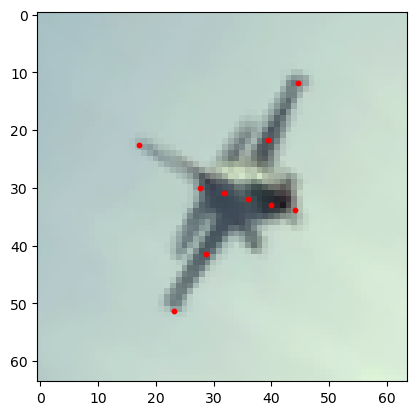

In [39]:
IMG_IDX = 625
IMG = dataset[IMG_IDX]
plt.imshow(torch.permute(IMG['image'], (1, 2, 0)))
# Unpack points into two lists: xs, ys
xs = [p[0] for p in IMG['points']]
ys = [p[1] for p in IMG['points']]
# Plot points as red circles
plt.scatter(xs, ys, c='red', s=10)  # s = point size

tensor(0.) tensor(9.2156)
torch.Size([10, 64, 64])


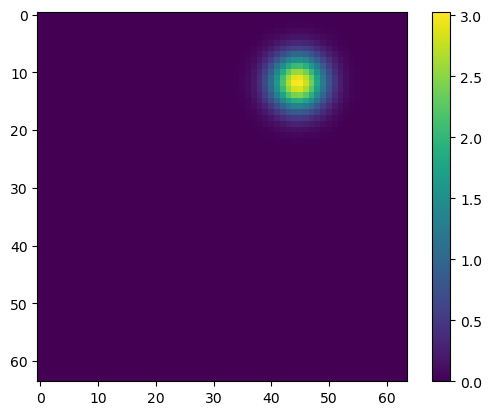

In [40]:
print(torch.min(IMG['heatmaps']), torch.max(IMG['heatmaps']))
print(IMG['heatmaps'].shape)
plt.imshow(IMG['heatmaps'][1])
plt.colorbar()

In [41]:
b = 1
c = 10
xs = torch.linspace(0.5, model_image_size-0.5, model_image_size) / model_image_size
ys = torch.linspace(0.5, model_image_size-0.5, model_image_size) / model_image_size
X, Y = torch.meshgrid(xs, ys, indexing="xy")
pts = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1)  # (N, 2), N = grid_size^2
pts = pts.view((1, 1,)+pts.shape).repeat((b, c, 1, 1))
pts[0][0]
rearranged_probabilities = IMG['heatmaps'].view((b, c, model_image_size*model_image_size, 1)).repeat((1, 1, 1, 2))
print(rearranged_probabilities.shape)
weighted_coords = rearranged_probabilities * pts
ev_coords = torch.sum(weighted_coords, dim=2)
print(ev_coords * model_image_size)

torch.Size([1, 10, 4096, 2])
tensor([[[ 9138.3047,  7045.6621],
         [ 9250.0088,  2528.9648],
         [ 8185.7510,  4545.9688],
         [ 4832.6553, 10599.7637],
         [ 5977.0747,  8581.6250],
         [ 5776.9526,  6241.5181],
         [ 3600.4800,  4738.6055],
         [ 8297.9668,  6844.6250],
         [ 7457.6284,  6643.5898],
         [ 6617.2900,  6442.5537]]])


In [42]:
print(IMG['points'])

tensor([[44.1206, 33.9027],
        [44.6661, 11.8475],
        [39.4695, 21.6971],
        [23.0970, 51.2582],
        [28.6849, 41.4025],
        [27.7078, 29.9762],
        [17.0805, 22.6377],
        [40.0174, 32.9210],
        [35.9142, 31.9394],
        [31.8110, 30.9578]])


tensor(0.) tensor(9.2156)


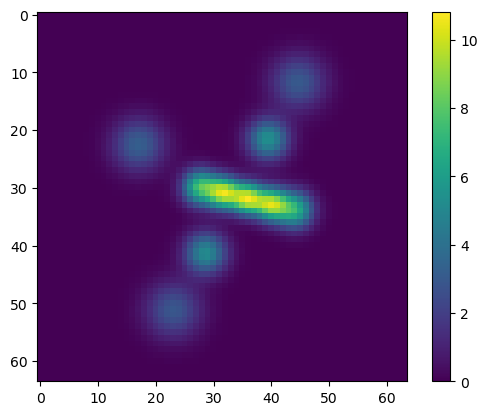

In [43]:
print(torch.min(IMG['heatmaps']), torch.max(IMG['heatmaps']))
plt.imshow(torch.sum(IMG['heatmaps'], axis=0))
plt.colorbar()

In [44]:
avg = torch.tensor([[0], [0], [0]], dtype=torch.float32)
for i in range(0, 900):
    img = dataset[i]
    avg[0] += torch.sum(img['heatmaps'][0]) / (model_image_size**2)
    avg[1] += torch.sum(img['heatmaps'][1]) / (model_image_size**2)
    avg[2] += torch.sum(img['heatmaps'][2]) / (model_image_size**2)
avg[0] /= len(range(0, 900))
avg[1] /= len(range(0, 900))
avg[2] /= len(range(0, 900))
print(avg)

tensor([[0.0500],
        [0.0500],
        [0.0500]])


In [45]:
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

for batch in loader:
    print(batch["frame"])
    print(batch["points"].shape)  # (B, N, 2)
    break

tensor([   0,    1,   29,   50,   63,   79,  103,  139,  181,  216,  248,  273,
         296,  325,  347,  366,  378,  420,  441,  480,  521,  557,  620,  743,
         831,  857,  879,  929, 1015, 1056, 1065, 1077, 1080, 1082, 1084, 1086,
        1088, 1090, 1095, 1102, 1105, 1111, 1122, 1130, 1141, 1155, 1165, 1187,
        1198, 1218, 1227, 1240, 1248, 1255, 1269, 1287, 1302, 1324, 1350])
torch.Size([59, 10, 2])


In [46]:
trial_number = 0

from datetime import datetime
import time

# instantiate generator, discriminator
# borrowed from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

# if not os.path.exists(datapath+"/trial_"+str(trial_number)):
#     os.mkdir(datapath+"/trial_"+str(trial_number))

device = torch.device("cuda:0" if (torch.cuda.is_available()) else "cpu")
print("device: ", device)

#print("Instantiating ImgToHeatmap")
print("Instantiating StackedHourglass")
# Create the generator
#model = ImgToHeatmap().to(device, dtype=torch.float32)
model = StackedHourglass(3, NUM_LANDMARKS).to(device, dtype=torch.float32)
model.apply(weights_init)
print(model)

# Setup Adam optimizers for both G and D
optimizer = optim.Adam(model.parameters(), lr=0.001, betas=(0.5, 0.999))
print("Model optimizer: \n", optimizer)

#criterion = nn.BCELoss()
#criterion = nn.CrossEntropyLoss(weight=torch.tensor([0.33, 0.33, 0.33, 0.01]))
""" ratio of positives to total for each channel
tensor([[0.0205],
        [0.0205],
        [0.0112]])
"""
"""
bce_weights = torch.tensor([[[25]], [[25]], [[25]]])
print("bce_weights")
print(bce_weights)
print("bce_weights shape:", bce_weights.shape)
criterion = nn.BCEWithLogitsLoss(pos_weight=bce_weights)
error_kind = "BCE"
"""
"""
criterion = nn.MSELoss()
error_kind = "spatial_softmax->mse"
"""
#criterion = nn.KLDivLoss(reduction='batchmean')
#criterion = nn.SmoothL1Loss(beta=0.01)
criterions = [nn.MSELoss() for j in range(5)]
#error_kind = "combined"
#criterion_coord = nn.SmoothL1Loss(beta=0.01)

clipper = WeightConstraint()

device:  cpu
Instantiating StackedHourglass
StackedHourglass(
  (unet1): UNet(
    (init_conv2): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
    (init_conv): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (downsize1): Down(
      (conv): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batch_norm0): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation0): LeakyReLU(negative_slope=True)
      (down): Conv2d(8, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (batch_norm): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): LeakyReLU(negative_slope=True)
      (conv_layers): SameSizeConv(
        (conv_layers): Sequential(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): LeakyReLU(negative

In [ ]:
# example
pred = torch.tensor([[[[1]], [[1000]], [[1000]]]], dtype=torch.float32)
label = torch.tensor([[[[0]], [[1]], [[1]]]], dtype=torch.float32)
print(F.sigmoid(torch.tensor([1000])))
print(criterion(pred, label))

In [ ]:
prev_models = []
model_dict = torch.load(f"{output_dir}/info_model_120725_100.pt")
model_loaded = StackedHourglass(3, NUM_LANDMARKS)
model_loaded.load_state_dict(model_dict['model_state_dict'])
prev_models.append(model_loaded)

In [47]:
iters = 0
epoch = 0
num_epochs = 1000
#k=500 # saving images of fixed_noise outputs
last_save = iters
break_flag = False

losses = []

example_idx = 110

In [107]:
b = 118
c = 10
xs = torch.linspace(0.5, model_image_size-0.5, model_image_size, device=device) / model_image_size
ys = torch.linspace(0.5, model_image_size-0.5, model_image_size, device=device) / model_image_size
X, Y = torch.meshgrid(xs, ys, indexing="xy")
pts = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1)  # (N, 2), N = grid_size^2
pts = pts.view((1, 1,)+pts.shape).repeat((b, c, 1, 1))
pts[0][0]

tensor([[0.0078, 0.0078],
        [0.0234, 0.0078],
        [0.0391, 0.0078],
        ...,
        [0.9609, 0.9922],
        [0.9766, 0.9922],
        [0.9922, 0.9922]])

In [52]:
# train the model
# borrowed from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

#train_D_only = False
#train_G_only = False
        
xs = torch.linspace(0.5, model_image_size-0.5, model_image_size, device=device) / model_image_size
ys = torch.linspace(0.5, model_image_size-0.5, model_image_size, device=device) / model_image_size
X, Y = torch.meshgrid(xs, ys, indexing="xy")
pts_template = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1)  # (N, 2), N = grid_size^2

print("Starting Training Loop...")
while (epoch < num_epochs) and (not break_flag):
    # For each batch in the dataloader
    should_break = False

    model.zero_grad()

    err_total_loss = 0
    
    for i, data in enumerate(loader, 0):
        print("Epoch\t"+str(epoch)+", batch\t"+str(i)+".", end="\n")
         # Check how the generator is doing by saving G's output on fixed_noise
        #if (epoch % k == 0) and (i == len(dataloader)-1):
        data_input = data['image']
        output = data['heatmaps']
        output_coords = data['points'] / model_image_size

        data_input = data_input.to(device, dtype=torch.float32)
        b = data_input.shape[0]
        c = output.shape[1]
        ###print("Batch size: ", batch_size)
        ###print(data_input.dtype)

        # print(dataseq.shape)

        # intermediate = None
        # for i in range(len(prev_models)):
        #     intermediate = prev_models[i](data_input)
        heatmap_predicted = model(data_input) # outputs logits
        #heatmap_predicted = model(torch.concat((data_input, intermediate), dim=1)) # outputs logits


        errs = []
        for j in range(len(heatmap_predicted)):
            errs.append(criterions[j](heatmap_predicted[j], output))
            if j == 0:
                print(f"Error for final: {errs[0].item()}")
            else:
                print(f"Error for intermediate heatmap {j}: {errs[j].item()}")
        losses.append((epoch, i, iters, {f"Stage {j} error": errs[j].item() for j in range(len(heatmap_predicted))} ) )

        err_sum = sum(errs)/len(errs)
        print(f"Average error: {err_sum.item()}")
        err_total_loss += err_sum.item() * b / batch_size
        err_sum.backward()

        # y_err = 1
        # err = criterion(heatmap_predicted, output)

        # pts = pts_template.view((1, 1,)+pts_template.shape).repeat((batch_size, num_channels, 1, 1))
        # rearranged_probabilities = torch.exp(heatmap_predicted).view((batch_size, num_channels, model_image_size*model_image_size, 1)).repeat((1, 1, 1, 2))
        # print(rearranged_probabilities.shape)
        # weighted_coords = rearranged_probabilities * pts
        # ev_coords = torch.sum(weighted_coords, dim=2)
        # print(ev_coords.shape)

        # err_coord = criterion_coord(ev_coords, output_coords)
        
        # y_heatmap = 1
        # y_coord = 50
        # err_sum = y_heatmap*err + y_coord*err_coord

        # #err.backward()
        # err_sum.backward()

        #optimizer.step()

        #time.sleep(1.00)
        # print(f"\t Heatmap error (KLDiv): {err.item()}")
        # print(f"\t Coordinate error (SmoothL1): {err_coord.item()}")
        # print(f"\t {error_kind}: {err_sum.item()}")
        # losses.append((epoch, i, iters, {f"{error_kind}_error": err_sum.item()},
        #                                 {f"y_heatmap_error": y_heatmap},
        #                                 {f"y_coord_error": y_coord} ))
        # print(f"\t Heatmap error (final): {err.item()}")
        # print(f"\t Coordinate error (SmoothL1): {err_coord.item()}")
        # print(f"\t {error_kind}: {err_sum.item()}")
        # losses.append((epoch, i, iters, {f"{error_kind}_error": err_sum.item()},
        #                                 {f"y_heatmap_error": y_heatmap},
        #                                 {f"y_coord_error": y_coord} ))

        iters += 1
    
        # if iters > 1000: # stop to quickly see results
        #     should_break = True
        #     break

    print(f"Total error: {err_total_loss}")
    losses.append((epoch, -1, iters, {f"Total error": err_total_loss} ) )
    
    optimizer.step()
    
    if should_break:
        break

    if (epoch+1) % 5 == 0:
        print(f"Saving results for example index {example_idx}")
        # output example output from model
        example_point = dataset[example_idx]
        image = torch.permute(example_point['image'], (1, 2, 0))
        plt.imshow(image.numpy())
        plt.savefig(f"{output_dir}/epoch{epoch}_in.png")
        plt.clf()

        input_example = example_point['image'].to(dtype=torch.float32)
        print(torch.min(input_example), torch.max(input_example))
        print(input_example.shape)
        model.eval()
        heatmap_pred = [x.detach() for x in model( torch.stack((input_example,)) )]
        model.train()
        heatmap_actual = example_point['heatmaps']
        print(heatmap_pred[0].shape)
        for i in range(NUM_LANDMARKS):
            pltmax = torch.max(heatmap_actual).item()
            plt.imshow(heatmap_actual.numpy()[i])
            plt.colorbar()
            plt.savefig(f"{output_dir}/epoch{epoch}_out_{i}_real.png")
            plt.clf()
            for j in range(len(heatmap_pred)):
                plt.imshow(heatmap_pred[j].numpy()[0][i])
                plt.colorbar()
                plt.savefig(f"{output_dir}/epoch{epoch}_out_{i}_{j}.png")
                plt.clf()


    epoch += 1
    #SIGMA_RATIO = ((SIGMA_RATIO - 0.05) * 0.996) + 0.05
    print(f"New SIGMA_RATIO: {SIGMA_RATIO}")

Starting Training Loop...
Epoch	39, batch	0.
Inter3.shape: torch.Size([59, 10, 64, 64])
Error for final: 0.13868604600429535
Error for intermediate heatmap 1: 0.15149357914924622
Error for intermediate heatmap 2: 0.13981163501739502
Error for intermediate heatmap 3: 0.1364060640335083
Error for intermediate heatmap 4: 0.1392674595117569
Average error: 0.14113295078277588
Epoch	39, batch	1.
Inter3.shape: torch.Size([59, 10, 64, 64])
Error for final: 0.1274370402097702
Error for intermediate heatmap 1: 0.13662812113761902
Error for intermediate heatmap 2: 0.12870772182941437
Error for intermediate heatmap 3: 0.12465564161539078
Error for intermediate heatmap 4: 0.12855546176433563
Average error: 0.12919679284095764
Epoch	39, batch	2.
Inter3.shape: torch.Size([59, 10, 64, 64])
Error for final: 0.15778937935829163
Error for intermediate heatmap 1: 0.17114001512527466
Error for intermediate heatmap 2: 0.15936389565467834
Error for intermediate heatmap 3: 0.15459711849689484
Error for interm

[E thread_pool.cpp:110] Exception in thread pool task: mutex lock failed: Invalid argument
[E thread_pool.cpp:110] Exception in thread pool task: mutex lock failed: Invalid argument


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [51]:
# new_beta2 = 0.99
# for param_group in optimizer.param_groups:
#     # param_group['betas'] is a tuple, so we create a new tuple
#     param_group['betas'] = (param_group['betas'][0], new_beta2)
new_lr = 0.0015
for param_group in optimizer.param_groups:
    param_group['lr'] = new_lr

In [ ]:
num_epochs = 2000

In [ ]:
losses

In [ ]:
losses[0]

Text(0, 0.5, 'Log loss')

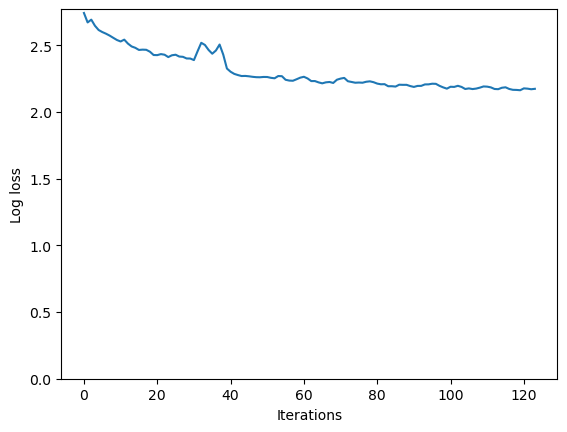

In [59]:
import math
plt.plot([x[0] for x in losses if x[1]==-1], [x[3]["Total error"] for x in losses if x[1]==-1])
plt.ylim(bottom=0)
plt.xlabel("Iterations")
plt.ylabel("Log loss")

In [ ]:
losses[-1][3][f"{error_kind}_error"]

In [26]:
torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': losses,
            }, f"{output_dir}/info_model_122125_800.pt")

In [27]:
model.eval()

StackedHourglass(
  (unet1): UNet(
    (init_conv2): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
    (init_conv): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (downsize1): Down(
      (conv): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batch_norm0): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation0): ReLU(inplace=True)
      (down): Conv2d(8, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (batch_norm): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): ReLU(inplace=True)
      (conv_layers): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(16, ep

In [ ]:
model_dict = torch.load(f"{output_dir}/info_model_112925_460.pt", weights_only=True)
model_dict['loss'][-1]

In [ ]:
model_loaded = UNet()
model_loaded.load_state_dict(model_dict['model_state_dict'])
model_loaded.eval()
model_loaded

In [ ]:
original_model_dict = torch.load(f"model_output_082625_2/info_model_082525_500.pt")
original_model_loaded = UNet()
original_model_loaded.load_state_dict(original_model_dict['model_state_dict'])

In [ ]:
model_dict = torch.load(f"{output_dir}/info_model_122125_800.pt")
model_loaded = StackedHourglass(3, NUM_LANDMARKS)
model_loaded.load_state_dict(model_dict['model_state_dict'])
model_loaded.eval()

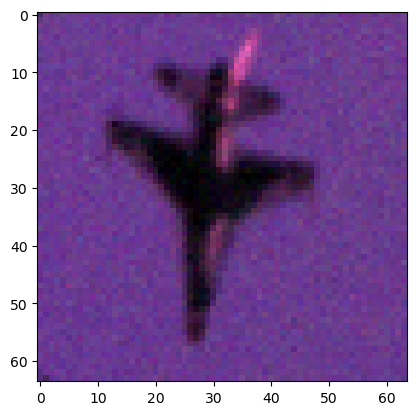

In [28]:
DATA_PT = 115
example_point = dataset[DATA_PT]
#example_point = dataset[115]
image = torch.permute(example_point['image'], (1, 2, 0))
plt.imshow(image.numpy())

torch.Size([3, 64, 64])


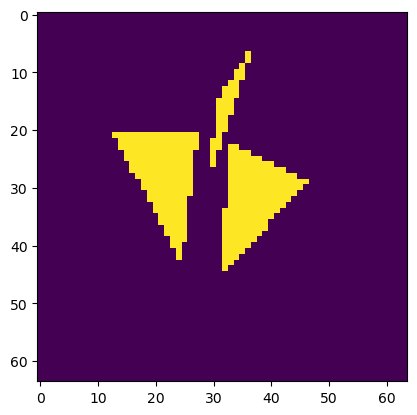

In [29]:
print(example_point['heatmaps'].shape)
plt.imshow(torch.sum(example_point['heatmaps'], dim=0).numpy())

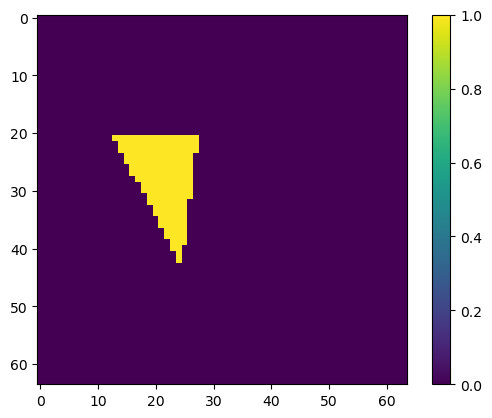

In [30]:
plt.imshow(example_point['heatmaps'][0].numpy())
plt.colorbar()

tensor(0.) tensor(0.9384)
torch.Size([3, 64, 64])
torch.Size([1, 3, 64, 64])


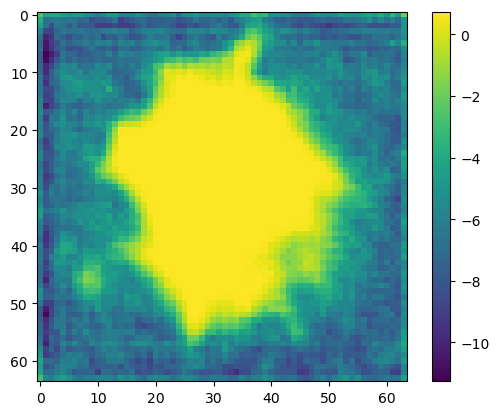

In [36]:
input_example = example_point['image'].to(dtype=torch.float32)
print(torch.min(input_example), torch.max(input_example))
print(input_example.shape)
heatmap_pred = model( torch.stack((input_example,)) ).detach()
print(heatmap_pred.shape)
plt.imshow(heatmap_pred[0].numpy()[0])
plt.colorbar()

In [ ]:
plt.imshow(torch.sum(heatmap_pred[0], dim=0).numpy(), vmin=0)
plt.colorbar()

In [ ]:
# provided by Gemini

# 2. Create a dictionary to store activations
activations = {}

# 3. Define the hook function
def get_activation(name):
    def hook(model, input, output):
        # .detach() removes the tensor from the computation graph
        activations[name] = output.detach()
    return hook

# 4. Register hooks on desired layers
model_loaded.unet1.upsize1.register_forward_hook(get_activation('unet1.upsize1'))
model_loaded.unet1.upsize2.register_forward_hook(get_activation('unet1.upsize2'))
model_loaded.unet1.upsize3.register_forward_hook(get_activation('unet1.upsize3'))
model_loaded.unet1.upsize4.register_forward_hook(get_activation('unet1.upsize4'))
model_loaded.unet1.batch_norm3.register_forward_hook(get_activation('unet1.batch_norm3'))
model_loaded.unet1.convs0.register_forward_hook(get_activation('unet1.convs0'))
model_loaded.unet1.convs1.register_forward_hook(get_activation('unet1.convs1'))
model_loaded.unet1.convs2.register_forward_hook(get_activation('unet1.convs2'))
model_loaded.unet1.convs3.register_forward_hook(get_activation('unet1.convs3'))

# 5. Perform a forward pass
#sample_input = torch.randn(1, 3, 32, 32) # Batch size 1, 3 channels, 32x32 image
_ = model_loaded( torch.stack((input_example,)) ) # Run the model

# 6. Access the stored activations
print(f"Shape of conv1 output: {activations['unet1.upsize1'].shape}")
print(f"Shape of batchnorm3 output: {activations['unet1.batch_norm3'].shape}")

In [ ]:
for p in [[1, 8], [2, 8], [3, 16], [4, 16]]:
    which_layer = "unet1.downsize"+str(p[0])
    num_channels = p[1]
    # Define the grid dimensions
    rows = num_channels//4 + 1
    columns = 4

    # 2. Create figure and axes
    # fig is the entire figure, axs is a 2D array of axes (subplots)
    fig, axs = plt.subplots(rows, columns, figsize=(8, 6))

    images = [np.random.rand(10, 10) * i for i in range(1, 5)]
    vmin = torch.min(activations[which_layer]).item()
    vmax = torch.max(activations[which_layer]).item()
    # 2. Create the normalization and mappable
    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = matplotlib.cm.ScalarMappable(norm=norm, cmap='viridis')

    titles = ["Channel "+str(i) for i in range(num_channels)]
    # 3. Iterate through axes and display images
    # Use .flatten() to turn the 2D array of axes into a 1D array for easy iteration
    for i, ax in enumerate(axs.flatten()):
        if i >= num_channels:
            break
        ax.imshow(activations[which_layer][0][i].numpy())
        ax.set_title(titles[i]) # Set a title for each subplot
        ax.axis('off') # Hide the axes ticks and labels for cleaner image presentation

    # Adjust layout for better spacing
    plt.tight_layout()
    fig.colorbar(sm, ax=axs, orientation='horizontal', label='Shared Scale')
    # Display the figure
    #plt.show()
    plt.savefig("down"+str(p[0])+"_"+str(DATA_PT)+".png")

In [ ]:
for p in [[0, 8], [1, 8], [2, 16], [3, 16]]:
    which_layer = "unet1.convs"+str(p[0])
    num_channels = p[1]
    # Define the grid dimensions
    rows = num_channels//4 + 1
    columns = 4

    # 2. Create figure and axes
    # fig is the entire figure, axs is a 2D array of axes (subplots)
    fig, axs = plt.subplots(rows, columns, figsize=(8, 6))

    images = [np.random.rand(10, 10) * i for i in range(1, 5)]
    vmin = torch.min(activations[which_layer]).item()
    vmax = torch.max(activations[which_layer]).item()
    # 2. Create the normalization and mappable
    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = matplotlib.cm.ScalarMappable(norm=norm, cmap='viridis')

    titles = ["Channel "+str(i) for i in range(num_channels)]
    # 3. Iterate through axes and display images
    # Use .flatten() to turn the 2D array of axes into a 1D array for easy iteration
    for i, ax in enumerate(axs.flatten()):
        if i >= num_channels:
            break
        ax.imshow(activations[which_layer][0][i].numpy())
        ax.set_title(titles[i]) # Set a title for each subplot
        ax.axis('off') # Hide the axes ticks and labels for cleaner image presentation

    # Adjust layout for better spacing
    plt.tight_layout()
    fig.colorbar(sm, ax=axs, orientation='horizontal', label='Shared Scale')
    # Display the figure
    plt.savefig("convs"+str(p[0])+"_"+str(DATA_PT)+".png")

In [ ]:
for p in [[1, 8], [2, 8], [3, 16], [4, 16]]:
    which_layer = "unet1.upsize"+str(p[0])
    num_channels = p[1]
    # Define the grid dimensions
    rows = num_channels//4 + 1
    columns = 4

    # 2. Create figure and axes
    # fig is the entire figure, axs is a 2D array of axes (subplots)
    fig, axs = plt.subplots(rows, columns, figsize=(8, 6))

    images = [np.random.rand(10, 10) * i for i in range(1, 5)]
    vmin = torch.min(activations[which_layer]).item()
    vmax = torch.max(activations[which_layer]).item()
    # 2. Create the normalization and mappable
    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = matplotlib.cm.ScalarMappable(norm=norm, cmap='viridis')

    titles = ["Channel "+str(i) for i in range(num_channels)]
    # 3. Iterate through axes and display images
    # Use .flatten() to turn the 2D array of axes into a 1D array for easy iteration
    for i, ax in enumerate(axs.flatten()):
        if i >= num_channels:
            break
        ax.imshow(activations[which_layer][0][i].numpy())
        ax.set_title(titles[i]) # Set a title for each subplot
        ax.axis('off') # Hide the axes ticks and labels for cleaner image presentation

    # Adjust layout for better spacing
    plt.tight_layout()
    fig.colorbar(sm, ax=axs, orientation='horizontal', label='Shared Scale')
    # Display the figure
    plt.savefig("up"+str(p[0])+"_"+str(DATA_PT)+".png")

In [ ]:
which_layer = "unet1.batch_norm3"
num_channels = 32
# Define the grid dimensions
rows = (num_channels-1)//4 + 1
columns = 4

unflattened_outputs = torch.unflatten(activations[which_layer], dim=1, sizes=(32, 8, 8))

# 2. Create figure and axes
# fig is the entire figure, axs is a 2D array of axes (subplots)
fig, axs = plt.subplots(rows, columns, figsize=(8, 6))

images = [np.random.rand(10, 10) * i for i in range(1, 5)]
vmin = torch.min(activations[which_layer]).item()
vmax = torch.max(activations[which_layer]).item()
# 2. Create the normalization and mappable
norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
sm = matplotlib.cm.ScalarMappable(norm=norm, cmap='viridis')

titles = ["Channel "+str(i) for i in range(num_channels)]
# 3. Iterate through axes and display images
# Use .flatten() to turn the 2D array of axes into a 1D array for easy iteration
for i, ax in enumerate(axs.flatten()):
    if i >= num_channels:
        break
    ax.imshow(unflattened_outputs[0][i].numpy())
    ax.set_title(titles[i]) # Set a title for each subplot
    ax.axis('off') # Hide the axes ticks and labels for cleaner image presentation

# Adjust layout for better spacing
plt.tight_layout()
fig.colorbar(sm, ax=axs, orientation='horizontal', label='Shared Scale')
# Display the figure
plt.savefig("fc_"+str(DATA_PT)+".png")

In [ ]:
plt.hist((heatmap_pred - example_point['heatmaps']).detach().numpy().flatten(), bins=100)

In [ ]:
plt.imshow(np.sum(example_point['heatmaps'].numpy(), axis=0), vmin=0, vmax=1)

In [ ]:
import frame_manager
import importlib
importlib.reload(frame_manager)

In [ ]:
SMOOTH_CONST = 1
# ---------- Main runner ----------
@torch.inference_mode()
def run_video_demo(model, source=0, device=None, window_name="Landmark Demo"):
    """
    source: 0 for webcam, or path to video file.
    model: a loaded torch.nn.Module that outputs heatmaps (B,C,Hh,Wh)
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval().to(device)

    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video source: {source}")

    t_prev = time.time()
    fps_ema = None

    try:
        while True:
            ok, frame = cap.read()
            if not ok: break

            # Keep a copy for drawing at native res
            out_frame = frame.copy()

            # Preprocess & infer
            tin, orig_wh = preprocess_frame(frame, device)
            # Optional: mixed precision for speed on GPU
            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                pred = F.softmax(model(tin), dim=1)                 # expect (1, C, Hh, Wh)
            if pred.dim() == 5: pred = pred[0]    # in case model returns (pred, aux)
            if pred.shape[0] == 1: pred = pred    # (1,C,Hh,Wh)
            _, C, Hh, Wh = pred.shape

            # Get coords in model-input space
            xs_in, ys_in = heatmaps_to_coords(pred)      # each (1,C)
            xs_in, ys_in = xs_in[0], ys_in[0]            # (C,)

            # Draw
            draw_points(out_frame, xs_in, ys_in, orig_wh)

            # FPS
            t_now = time.time()
            fps = 1.0 / max(t_now - t_prev, 1e-6)
            fps_ema = fps if fps_ema is None else 0.9*fps_ema + 0.1*fps
            t_prev = t_now
            put_fps(out_frame, fps_ema)

            cv2.imshow(window_name, out_frame)
            key = cv2.waitKey(1) & 0xFF
            if key in (27, ord('q')):  # ESC or q
                break
    finally:
        cap.release()
        cv2.destroyAllWindows()


class LatestFrameGrabber:
    """Continuously grabs frames on a background thread and keeps only the most recent one."""
    def __init__(self, source=0):
        self.cap = cv2.VideoCapture(source)
        if not self.cap.isOpened():
            raise RuntimeError(f"Could not open video source: {source}")
        # Best-effort: keep tiny buffer (works on some backends; harmless otherwise)
        try:
            self.cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)
        except Exception:
            pass
        self.lock = threading.Lock()
        self.frame = None
        self.stopped = False
        self.t = threading.Thread(target=self._update, daemon=True)
        self.t.start()

    def _update(self):
        while not self.stopped:
            ok, f = self.cap.read()
            if not ok:
                self.stopped = True
                break
            with self.lock:
                self.frame = f

    def read(self):
        with self.lock:
            return None if self.frame is None else self.frame.copy()

    def release(self):
        self.stopped = True
        try:
            self.t.join(timeout=1.0)
        except Exception:
            pass
        self.cap.release()

import time, cv2, torch

@torch.inference_mode()
def run_video_demo_fixed_rate(model, source=0, device=None, window_name="Landmark Demo",
                              sample_hz=15.0, show_fps=True):
    """
    Samples the *latest* frame every 1/sample_hz seconds, runs inference on that frame,
    and displays only those results. Drops frames between ticks to avoid latency buildup.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval().to(device)

    grab = LatestFrameGrabber(source)  # from previous code: grabs frames on a thread
    dt = 1.0 / float(max(sample_hz, 1e-6))
    next_t = time.perf_counter()  # monotonic clock

    disp_fps_ema = None
    try:
        while True:
            now = time.perf_counter()
            # sleep until the next scheduled tick (keeps rate steady, avoids drift)
            if now < next_t:
                time.sleep(next_t - now)
                continue
            # schedule the following tick
            next_t += dt

            t0 = time.perf_counter()
            frame = grab.read()
            if frame is None:
                # No new frame yet; skip this tick but keep schedule
                continue

            out_frame = frame.copy()

            # Preprocess & infer on the ticked frame
            tin, orig_wh = preprocess_frame(frame, device)
            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                tin = tin.to(dtype=torch.float32)
                pred = model(tin)  # (1, C, Hh, Wh)

            xs_in, ys_in = heatmaps_to_coords(pred)   # each (1, C) in model-input coords
            xs_in, ys_in = xs_in[0], ys_in[0]
            draw_points(out_frame, xs_in, ys_in, orig_wh)

            # Display + UI FPS (UI FPS may be ~ sample_hz)
            t1 = time.perf_counter()
            ui_fps = 1.0 / max(t1 - t0, 1e-6)
            disp_fps_ema = ui_fps if disp_fps_ema is None else 0.9*disp_fps_ema + 0.1*ui_fps
            if show_fps:
                put_fps(out_frame, disp_fps_ema)
                cv2.putText(out_frame, f"Sample: {sample_hz:.1f} Hz",
                            (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2, cv2.LINE_AA)

            cv2.imshow(window_name, out_frame)
            key = cv2.waitKey(1) & 0xFF
            if key in (27, ord('q')):
                break

            # If inference was slower than dt, catch the schedule up (drop extra ticks)
            # so next tick isn't delayed by accumulated lag.
            now2 = time.perf_counter()
            while next_t < now2 - 1e-4:
                next_t += dt
    finally:
        grab.release()
        cv2.destroyAllWindows()

import time, cv2, torch

@torch.inference_mode()
def run_video_demo_auto(model, source=0, device=None, window_name="Landmark Demo",
                        sample_hz=15.0, show_fps=True):
    """
    - If source is webcam (fps not available) → run at fixed sample_hz (e.g. 15 Hz).
    - If source is video file (fps available) → throttle playback to the file's FPS.
    """

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval().to(device)

    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video source: {source}")

    # Try to read FPS from file
    fps_file = cap.get(cv2.CAP_PROP_FPS)
    if fps_file is None or fps_file <= 1e-2:  # webcams often report 0
        mode = "webcam"
        dt = 1.0 / float(max(sample_hz, 1e-6))   # fixed rate
        print(f"[INFO] Webcam mode: target {sample_hz} Hz")
    else:
        mode = "file"
        dt = 1.0 / fps_file
        print(f"[INFO] Video file mode: target {fps_file:.2f} FPS")

    next_t = time.perf_counter()
    disp_fps_ema = None

    prev_xs_in_smooth, prev_ys_in_smooth = None, None

    prev_mask = [None] * 4
    prev_pred = None

    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            out_frame = frame.copy()

            # preprocess
            tin, orig_wh = frame_manager.preprocess_frame(frame, device)

            # inference
            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                pred = F.softmax(model(tin), dim=1).detach()  # (1, C, H, W)
                # pred = model(tin).detach()  # (1, C, H, W)
            out_frame_2 = out_frame.copy().astype(np.float32)
            if (prev_pred is None):
                pred_smooth = pred
            else:
                pred_smooth = 0.3*pred + 0.7*prev_pred
            prev_pred = pred_smooth
            pred_round = torch.round(pred_smooth)
            for i in range(0, 3): 
                colored_heatmap = torch.permute(torch.tensor([255, 255, 255]) - torch.tensor(frame_manager.COLORS[i]).repeat(128, 128, 1), (2, 0, 1)) * pred_round[0][i].repeat(3, 1, 1).view(1, 3, 128, 128)
                # print(out_frame_2.shape)
                # print(colored_heatmap.shape)
                new_img = F.interpolate(colored_heatmap, size=(324, 324), mode='bilinear').to(torch.uint8)
                new_img_2 = (torch.ones(new_img.shape)*255 - new_img*0.5)/255
                # print(new_img.shape)
                mask = torch.permute(new_img_2, (0, 2, 3, 1)).view(324, 324, 3).numpy()
                
                out_frame_2 = out_frame_2 * mask

            out_frame_2 = out_frame_2.astype(np.uint8)

            xs_in, ys_in = frame_manager.heatmaps_to_coords(pred)
            xs_in, ys_in = xs_in[0], ys_in[0]
            if prev_xs_in_smooth is None:
                xs_in_smooth, ys_in_smooth = xs_in, ys_in
            else:
                xs_in_smooth, ys_in_smooth = xs_in*SMOOTH_CONST + prev_xs_in_smooth*(1-SMOOTH_CONST), ys_in*SMOOTH_CONST + prev_ys_in_smooth*(1-SMOOTH_CONST)
            # frame_manager.draw_points(out_frame, xs_in_smooth, ys_in_smooth, orig_wh)
            #prev_xs_in_smooth, prev_ys_in_smooth = xs_in_smooth, ys_in_smooth

            # UI FPS
            now = time.perf_counter()
            ui_fps = 1.0 / max(now - next_t + dt, 1e-6)
            disp_fps_ema = ui_fps if disp_fps_ema is None else 0.9*disp_fps_ema + 0.1*ui_fps
            if show_fps:
                frame_manager.put_fps(out_frame, disp_fps_ema)

            cv2.imshow(window_name, out_frame_2)
            # cv2.imshow(window_name, out_frame)
            key = cv2.waitKey(1) & 0xFF
            if key in (27, ord('q')):
                break

            # pacing
            if mode == "webcam":
                # sleep until next scheduled tick
                now = time.perf_counter()
                if now < next_t:
                    time.sleep(next_t - now)
                next_t += dt
            else:  # file
                wait_ms = int(max(1, dt * 1000))
                if cv2.waitKey(wait_ms) & 0xFF in (27, ord('q')):
                    break

    finally:
        cap.release()
        cv2.destroyAllWindows()


In [ ]:
# or a file:
run_video_demo_auto(model_loaded, source="plane_2.mov", sample_hz=60.0)